# Data Augmentation

Empezaremos utilizando esta técnica que nos va a proveer la posibilidad de crear nuevos elementos a las diferentes clases de salida haciendo modificaciones a las ya existenes

## Configuración inicial

In [2]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

In [3]:
from tensorflow.keras import datasets
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [8]:
ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))

def preparar_imagen(image, label):
    image = tf.image.resize(image, (256, 256), method='bilinear')
    return image, label

ds = ds.map(preparar_imagen).shuffle(1000).batch(10)

## Visualizo el set de datos

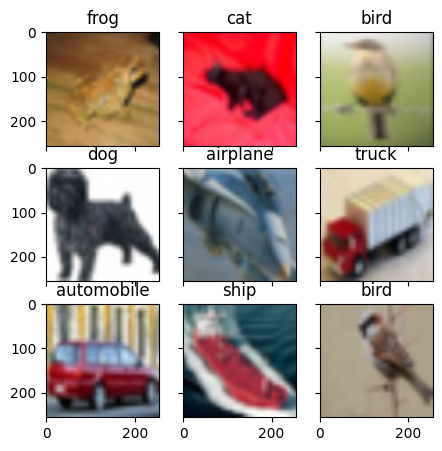

In [10]:
import matplotlib.pyplot as plt

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5,5))

for images, labels in ds.take(1):
  for i in range(3):
      for j in range(3):
          ax[i][j].imshow(images[i*3+j].numpy().astype("uint8"))
          ax[i][j].set_title(class_names[labels[i*3+j][0]])
plt.show()

## Modifico los atributos para cambiar elementos de la misma muestra

In [11]:
out_height, out_width = 128,256
resize = tf.keras.layers.Resizing(out_height, out_width)
height = tf.keras.layers.RandomHeight(0.3)
width = tf.keras.layers.RandomWidth(0.3)
zoom = tf.keras.layers.RandomZoom(0.3)

flip = tf.keras.layers.RandomFlip("horizontal_and_vertical")
rotate = tf.keras.layers.RandomRotation(0.2)
crop = tf.keras.layers.RandomCrop(out_height, out_width)
translation = tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2)

brightness = tf.keras.layers.RandomBrightness([-0.8,0.8])
contrast = tf.keras.layers.RandomContrast(0.2)

## Visualizo cambios realizados

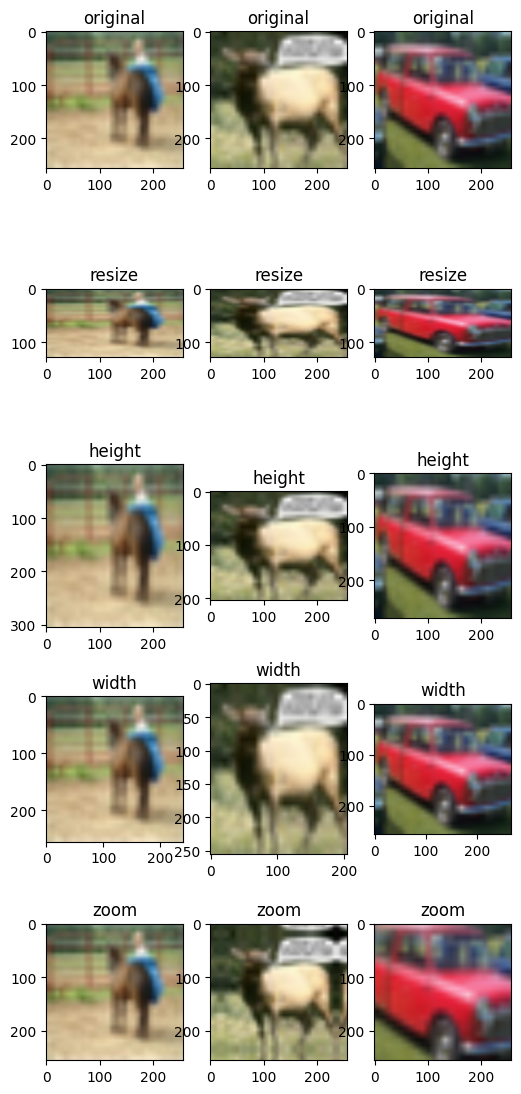

In [12]:
fig, ax = plt.subplots(5, 3, figsize=(6,14))
for images, labels in ds.take(1):

  for i in range(3):
        ax[0][i].imshow(images[i].numpy().astype("uint8"))
        ax[0][i].set_title("original")
        # resize
        ax[1][i].imshow(resize(images[i]).numpy().astype("uint8"))
        ax[1][i].set_title("resize")
        # height
        ax[2][i].imshow(height(images[i]).numpy().astype("uint8"))
        ax[2][i].set_title("height")
        # width
        ax[3][i].imshow(width(images[i]).numpy().astype("uint8"))
        ax[3][i].set_title("width")
        # zoom
        ax[4][i].imshow(zoom(images[i]).numpy().astype("uint8"))
        ax[4][i].set_title("zoom")
plt.show()

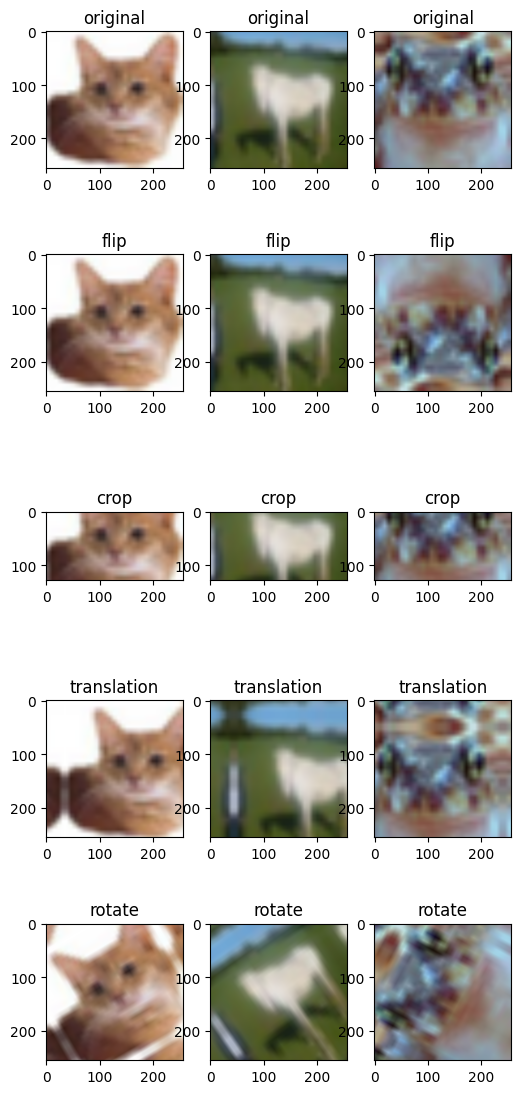

In [13]:
fig, ax = plt.subplots(5, 3, figsize=(6,14))
for images, labels in ds.take(1):
  for i in range(3):
        ax[0][i].imshow(images[i].numpy().astype("uint8"))
        ax[0][i].set_title("original")
        # flip
        ax[1][i].imshow(flip(images[i]).numpy().astype("uint8"))
        ax[1][i].set_title("flip")
        # crop
        ax[2][i].imshow(crop(images[i]).numpy().astype("uint8"))
        ax[2][i].set_title("crop")
        # translation
        ax[3][i].imshow(translation(images[i]).numpy().astype("uint8"))
        ax[3][i].set_title("translation")
        # rotate
        ax[4][i].imshow(rotate(images[i]).numpy().astype("uint8"))
        ax[4][i].set_title("rotate")
plt.show()


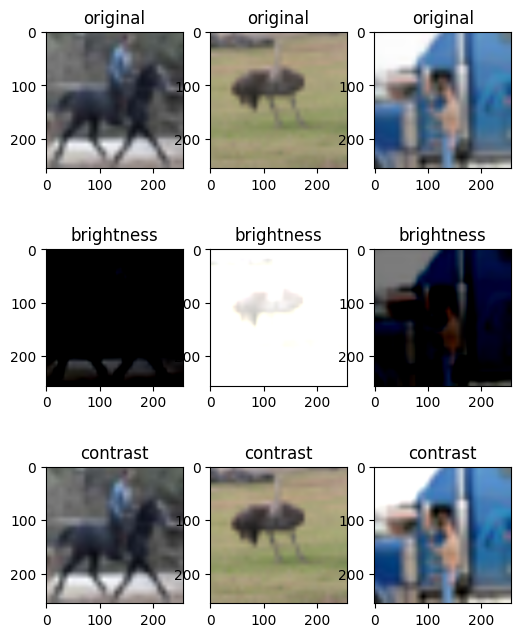

In [14]:
fig, ax = plt.subplots(3, 3, figsize=(6,8))
for images, labels in ds.take(1):

  for i in range(3):
        ax[0][i].imshow(images[i].numpy().astype("uint8"))
        ax[0][i].set_title("original")
        # brightness
        ax[1][i].imshow(brightness(images[i]).numpy().astype("uint8"))
        ax[1][i].set_title("brightness")
        # contrast
        ax[2][i].imshow(contrast(images[i]).numpy().astype("uint8"))
        ax[2][i].set_title("contrast")
plt.show()